In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('SATS','UMBF'), 
         ('SATS','SPXC'), 
         ('SATS','DY'), 
         ('HL','UMBF'), 
         ('HL', 'SPXC'),
         ('HL', 'DY'), 
         ('BWA','UMBF'), 
         ('BWA', 'SPXC'), 
         ('BWA','DY')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

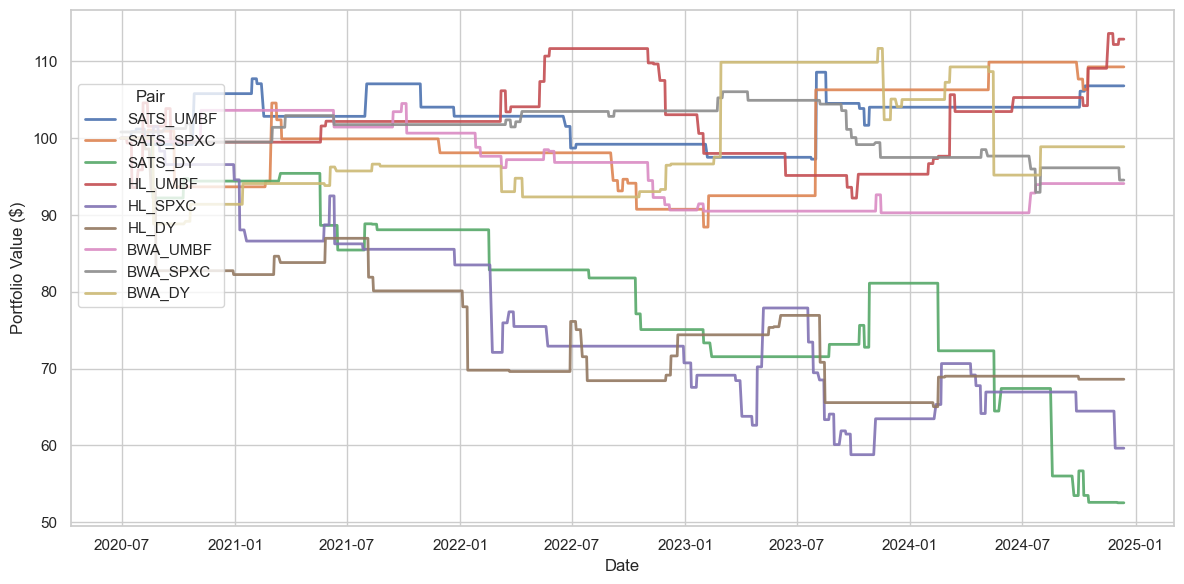

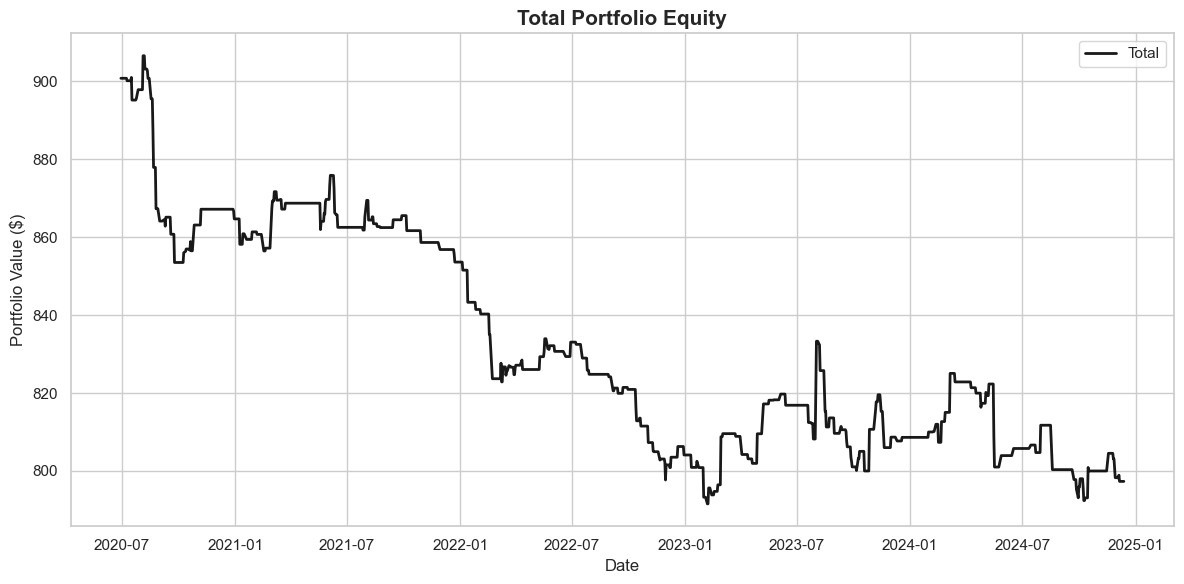

Summary
SATS_UMBF: Final Value = $106.81, Total Return = 6.81%, Trades = 22
SATS_SPXC: Final Value = $109.28, Total Return = 9.28%, Trades = 20
SATS_DY: Final Value = $52.54, Total Return = -47.46%, Trades = 28
HL_UMBF: Final Value = $112.89, Total Return = 12.89%, Trades = 37
HL_SPXC: Final Value = $59.65, Total Return = -40.35%, Trades = 42
HL_DY: Final Value = $68.62, Total Return = -31.38%, Trades = 28
BWA_UMBF: Final Value = $94.09, Total Return = -5.91%, Trades = 25
BWA_SPXC: Final Value = $94.55, Total Return = -6.20%, Trades = 29
BWA_DY: Final Value = $98.88, Total Return = -1.12%, Trades = 28

Total Portfolio Performance
Initial Portfolio Value: $900.80
Final Portfolio Value:   $797.33
Total Return:            -11.49%

Sharpe Ratios
SATS_UMBF: Sharpe Ratio = 0.23
SATS_SPXC: Sharpe Ratio = 0.24
SATS_DY: Sharpe Ratio = -0.87
HL_UMBF: Sharpe Ratio = 0.34
HL_SPXC: Sharpe Ratio = -0.63
HL_DY: Sharpe Ratio = -0.63
BWA_UMBF: Sharpe Ratio = -0.28
BWA_SPXC: Sharpe Ratio = -0.36
BWA_DY:

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)